In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [64]:

def read_xy_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Extract column labels from the second line (assumes fixed format)
    label_x, label_y = lines[1].replace('(labels "', "").replace('")', "").split('" "')

    data_blocks = {}
    current_label = None
    data_start = False

    for line in lines:
        line = line.strip()

        # Detect new data block
        if line.startswith("((xy/key/label"):
            current_label = line.split('"')[1]  # Extract label without regex
            data_blocks[current_label] = []
            data_start = True
            continue
        
        # Stop if end of data block
        if data_start and line.endswith(")"):
            continue
        
        # Read numerical data
        if data_start and line:
            values = line.split()
            data_blocks[current_label].append([float(values[0]), float(values[1])])

    # Convert blocks into DataFrames and merge
    merged_df = None
    for i, (key, data) in enumerate(data_blocks.items()):
        df = pd.DataFrame(data, columns=[label_x, key])  # Name the second column with block label
        if merged_df is None:
            merged_df = df
        else:
            merged_df = pd.merge(merged_df, df, on=label_x, how="outer")  # Merge on the first column

    
    return merged_df, label_x

In [65]:
def read_xy_file_stack_all(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Extract column labels from the second line (assumes fixed format)
    label_x, label_y = lines[1].replace('(labels "', "").replace('")', "").split('" "')

    data_blocks = {}
    current_label = None
    data_start = False

    for line in lines:
        line = line.strip()

        # Detect new data block
        if line.startswith("((xy/key/label"):
            current_label = line.split('"')[1]  # Extract label without regex
            data_blocks[current_label] = []
            data_start = True
            continue
        
        # Stop if end of data block
        if data_start and line.endswith(")"):
            continue
        
        # Read numerical data
        if data_start and line:
            values = line.split()
            data_blocks[current_label].append([float(values[0]), float(values[1])])

    # Convert blocks into DataFrames and concatenate
    concatenated_df = None
    for i, (key, data) in enumerate(data_blocks.items()):
        df = pd.DataFrame(data, columns=[label_x, key])  # Name the second column with block label
        if concatenated_df is None:
            concatenated_df = df
        else:
            concatenated_df = pd.concat([concatenated_df, df], axis=1)  # Concatenate horizontally

    return concatenated_df, label_x

In [66]:
# VALIDATION OF THE TURBULENCE MODEL - EXPERIMENTAL DATA

# x means x/H
# cp_orig is the original Cp data, referenced to conditions near x/H=-4
# cp has been shifted for convenience so that Cp=0 near x/H=40 (see Eca et al: AIAA-2009-3647, AIAA-2007-4089, AIAA-2005-4728)

# y is y/H, u is u/Uref, v is v/Uref, 
# uu is 1000*u'u'/Uref**2
# vv is 1000*v'v'/Uref**2
# uv is 1000*u'v'/Uref**2

file = r'C:\Users\Korisnik\Documents\SARENA\LUT - SARENA M1S2\Turbulence Models\k_omega_fine_mesh.xlsx'
df_theoretical = pd.read_excel(file, sheet_name='Sheet3')
df_theoretical.columns
df_theoretical
df_theoretical = pd.concat([
    df_theoretical.iloc[:, 0].astype(str).str.split(expand=True),
    df_theoretical.iloc[:, 1].astype(str).str.split(expand=True),
    df_theoretical.iloc[:, 4].astype(str).str.split(expand=True),
    df_theoretical.iloc[:, 10].astype(str).str.split(expand=True)
], axis=1)
df_theoretical = df_theoretical.apply(pd.to_numeric, errors='coerce')
df_theoretical.columns = ['x_cp', 'cp', 'cp_orig', 'x_cf', 'cf', 'cf_error', 'id1', 'y1', 'u1', 'v1', 'uu1', 'vv1', 'uv1', 'uuu1', 'uvv1', 'vuu1', 'vvv1', 'id6', 'y6', 'u6', 'v6', 'uu6', 'vv6', 'uv6', 'uuu6', 'uvv6', 'vuu6', 'vvv6']
#df_theoretical = df_theoretical.apply(pd.to_numeric, errors='coerce')
#df_theoretical = df_theoretical.dropna()
[df_theoretical['x_cf']]

[0     -3.956
 1     -1.804
 2     -0.804
 3      0.484
 4      1.804
 5      2.804
 6      3.804
 7      4.804
 8      5.882
 9      7.090
 10     7.978
 11     9.196
 12    11.196
 13    13.196
 14    16.196
 15    20.196
 16    24.136
 17    28.130
 18    32.196
 19    35.994
 20       NaN
 21       NaN
 22       NaN
 23       NaN
 24       NaN
 25       NaN
 26       NaN
 27       NaN
 28       NaN
 29       NaN
 30       NaN
 31       NaN
 32       NaN
 33       NaN
 34       NaN
 35       NaN
 36       NaN
 37       NaN
 38       NaN
 39       NaN
 40       NaN
 41       NaN
 42       NaN
 43       NaN
 44       NaN
 45       NaN
 46       NaN
 47       NaN
 48       NaN
 49       NaN
 50       NaN
 51       NaN
 52       NaN
 53       NaN
 Name: x_cf, dtype: float64]

In [67]:
# THEORETICAL DATA - STANDARD K-EPSILON MODEL

# x means x/H
# cp_orig is the original Cp data, referenced to conditions near x/H=-4
# cp has been shifted for convenience so that Cp=0 near x/H=40 (see Eca et al: AIAA-2009-3647, AIAA-2007-4089, AIAA-2005-4728)


# y is y/H, u is u/Uref, v is v/Uref, 
# uu is 1000*u'u'/Uref**2
# vv is 1000*v'v'/Uref**2
# uv is 1000*u'v'/Uref**2
# triple moments are 10000*u'u'u'/Uref**3 (for example)

file_path = r"exercise8/ke_cp4h_adjusted.xy"  # Update with your actual file path
df, x_label = read_xy_file(file_path)
df.columns = ['x-cp-ke', 'cp-ke']


file_path1 = r"exercise8/ke_cf4h.xy"  # Update with your actual file path
df1, x_label1 = read_xy_file(file_path1)
df1.columns = ['x-cf-ke', 'cf-ke']

file_path2 = r"exercise8/ke_velocity_profile"  # Update with your actual file path
df2, x_label2 = read_xy_file_stack_all(file_path2)
df2.columns = ['u6-ke', 'y6-ke', 'u1-ke', 'y1-ke']


file_path3 = r"exercise8/ke-y-over-h-over-uu-over-uinf2.xy"  # Update with your actual file path
df3, x_label3 = read_xy_file_stack_all(file_path3)
df3.columns = ['uu6-ke', 'y6-uu6-ke', 'uu1-ke', 'y1-uu1-ke' ]

file_path4 = r"exercise8/ke-y-over-h-over-vv-over-uinf2.xy"  # Update with your actual file path
df4, x_label4 = read_xy_file_stack_all(file_path4)
df4.columns = [ 'vv6-ke', 'y6-vv6-ke',  'vv1-ke', 'y1-vv1-ke']

file_path5 = r"exercise8/ke-y-over-h-over-uv-over-uinf2.xy"  # Update with your actual file path
df5, x_label5 = read_xy_file_stack_all(file_path5)
df5.columns = [ 'uv6-ke', 'y6-uv6-ke', 'uv1-ke', 'y1-uv1-ke']

df_ke = pd.concat([df, df1, df2, df3, df4, df5], axis=1)
df_ke = df_ke.loc[:, ~df_ke.columns.duplicated()]  # Remove duplicate columns
df_ke



#plt.figure(figsize=(10, 6))
#plt.plot(df_ke['uv6-ke'], df_ke['y6-uv6-ke'], label='Experimental Data', marker='o')

,x-cp-ke,cp-ke,x-cf-ke,cf-ke,u6-ke,y6-ke,u1-ke,y1-ke,uu6-ke,y6-uu6-ke,uu1-ke,y1-uu1-ke,vv6-ke,y6-vv6-ke,vv1-ke,y1-vv1-ke,uv6-ke,y6-uv6-ke,uv1-ke,y1-uv1-ke
0,-1.100000,-0.022043,-1.100000,0.005635,0.000000,0.000000,-0.094227,0.057648,4.78407,0.000000,1.23386,0.000000,4.81130,0.000000,1.20329,0.000000,-0.284566,0.000000,0.160398,0.000000
1,-1.100000,-0.022043,-1.100000,0.005635,0.073304,0.000300,-0.094174,0.065027,4.78735,0.000300,1.23460,0.000309,4.82403,0.000300,1.19440,0.000309,-0.270543,0.000300,0.149696,0.000309
2,-1.091920,-0.023864,-1.091920,0.005763,0.073769,0.000612,-0.094164,0.051032,4.79704,0.000612,1.23640,0.000654,4.85311,0.000612,1.17705,0.000654,-0.262169,0.000612,0.140450,0.000654
3,-1.091920,-0.023864,-1.091920,0.005763,0.074239,0.000938,-0.093999,0.045111,4.81312,0.000938,1.23893,0.001041,4.87906,0.000938,1.17136,0.001041,-0.273636,0.000938,0.142446,0.001041
4,-1.083640,-0.027577,-1.083640,0.005716,0.074716,0.001283,-0.093989,0.073241,4.83555,0.001283,1.24236,0.001476,4.90422,0.001283,1.17433,0.001476,-0.282412,0.001283,0.142756,0.001476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1041,0.438407,-0.004721,0.438407,0.002423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1042,0.467983,-0.006196,0.467983,0.002433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1043,0.467983,-0.006196,0.467983,0.002433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1044,0.500000,-0.007533,0.500000,0.002440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


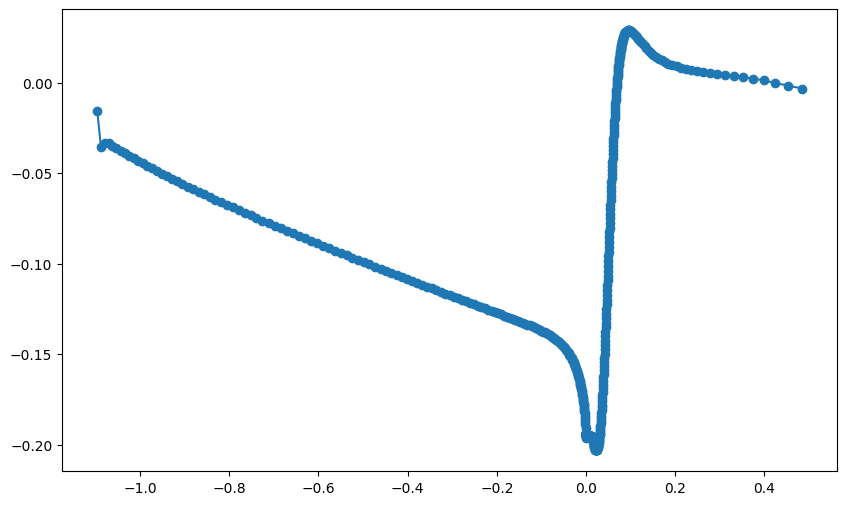

In [68]:
# THEORETICAL DATA - STANDARD K-OMEGA MODEL

# x means x/H
# cp_orig is the original Cp data, referenced to conditions near x/H=-4
# cp has been shifted for convenience so that Cp=0 near x/H=40 (see Eca et al: AIAA-2009-3647, AIAA-2007-4089, AIAA-2005-4728)


# y is y/H, u is u/Uref, v is v/Uref, 
# uu is 1000*u'u'/Uref**2
# vv is 1000*v'v'/Uref**2
# uv is 1000*u'v'/Uref**2
# triple moments are 10000*u'u'u'/Uref**3 (for example)

file_path_1 = r"exercise8/ko-cp-coeff-adjusted1.xy"  # Update with your actual file path
df_1, x_label = read_xy_file(file_path_1)
df_1.columns = ['x-cp-ko', 'cp-ko']


file_path_2 = r"exercise8/ko-cf-coeff.xy"  # Update with your actual file path
df_2, x_label_2 = read_xy_file(file_path_2)
df_2.columns = ['x-cf-ko', 'cf-ko']


file_path_3 = r"exercise8/ko-velocity_profile.xy"  # Update with your actual file path
df_3, x_label_3 = read_xy_file_stack_all(file_path_3)
df_3.columns = ['u6-ko', 'y6-ko', 'u1-ko', 'y1-ko']


file_path_4 = r"exercise8/ko-y-over-h-over-uu-over-uinf2.xy"  # Update with your actual file path
df_4, x_label_4 = read_xy_file_stack_all(file_path_4)
df_4.columns = ['uu6-ko', 'y6-uu6-ko', 'uu1-ko', 'y1-uu1-ko']

file_path_5 = r"exercise8/ko-y-over-h-over-vv-over-uinf2.xy"  # Update with your actual file path
df_5, x_label_5 = read_xy_file_stack_all(file_path_5)
df_5.columns = [ 'vv6-ko', 'y6-vv6-ko', 'vv1-ko', 'y1-vv1-ko']

file_path_6 = r"exercise8/ko-y-over-h-over-uv-over-uinf2.xy"  # Update with your actual file path
df_6, x_label_6 = read_xy_file_stack_all(file_path_6)
df_6.columns = [ 'uv6-ko', 'y6-uv6-ko', 'uv1-ko', 'y1-uv1-ko']

df_ko = pd.concat([df_1, df_2, df_3, df_4, df_5, df_6], axis=1)
#df_ke = df_ke.dropna()


#df_ko_sst = df_ko_sst.loc[:, ~df_ko_sst.columns.duplicated()]  # Remove duplicate columns
df_ko

plt.figure(figsize=(10, 6))
plt.plot(df_ko['x-cp-ko'], df_ko['cp-ko'], label='Experimental Data', marker='o')

plt.show()

In [69]:
# THEORETICAL DATA - SST K-OMEGA MODEL

# x means x/H
# cp_orig is the original Cp data, referenced to conditions near x/H=-4
# cp has been shifted for convenience so that Cp=0 near x/H=40 (see Eca et al: AIAA-2009-3647, AIAA-2007-4089, AIAA-2005-4728)


# y is y/H, u is u/Uref, v is v/Uref, 
# uu is 1000*u'u'/Uref**2
# vv is 1000*v'v'/Uref**2
# uv is 1000*u'v'/Uref**2
# triple moments are 10000*u'u'u'/Uref**3 (for example)

file_path_11 = r"exercise8/ko_sst-cp-coeff-adjusted.xy"  # Update with your actual file path
df_11, x_label_11 = read_xy_file(file_path_11)
df_11.columns = ['x-cp-ko-sst', 'cp-ko-sst']


file_path_22 = r"exercise8/ko_sst-cf-coef.xy"  # Update with your actual file path
df_22, x_label_22 = read_xy_file(file_path_22)
df_22.columns = ['x-cf-ko-sst', 'cf-ko-sst']


file_path_33 = r"exercise8/ko_sst-velocity_profile.xy"  # Update with your actual file path
df_33, x_label_33 = read_xy_file_stack_all(file_path_33)
df_33.columns = ['u6-ko-sst', 'y6-ko-sst', 'u1-ko-sst', 'y1-ko-sst']


file_path_44 = r"exercise8/ko_sst-y-over-h-over-uu-over-uinf2.xy"  # Update with your actual file path
df_44, x_label_44 = read_xy_file_stack_all(file_path_44)
df_44.columns = ['uu6-ko-sst', 'y6-uu6-ko-sst', 'uu1-ko-sst', 'y1-uu1-ke']

file_path_55 = r"exercise8/ko_sst-y-over-h-over-vv-over-uinf2.xy"  # Update with your actual file path
df_55, x_label_55 = read_xy_file_stack_all(file_path_55)
df_55.columns = [ 'vv6-ko-sst', 'y6-vv6-ko-sst', 'vv1-ko-sst', 'y1-vv1-ko-sst']

file_path_66 = r"exercise8/ko_sst-y-over-h-over-uv-over-uinf2.xy"  # Update with your actual file path
df_66, x_label_66 = read_xy_file_stack_all(file_path_66)
df_66.columns = [ 'uv6-ko-sst', 'y6-vv6-ko-sst', 'uv1-ko-sst', 'y1-vv1-ko-sst']

df_ko_sst = pd.concat([df_11, df_22, df_33, df_44, df_55, df_66], axis=1)
#df_ke = df_ke.dropna()


#df_ko_sst = df_ko_sst.loc[:, ~df_ko_sst.columns.duplicated()]  # Remove duplicate columns
df_ko_sst 


,x-cp-ko-sst,cp-ko-sst,x-cf-ko-sst,cf-ko-sst,u6-ko-sst,y6-ko-sst,u1-ko-sst,y1-ko-sst,uu6-ko-sst,y6-uu6-ko-sst,uu1-ko-sst,y1-uu1-ke,vv6-ko-sst,y6-vv6-ko-sst,vv1-ko-sst,y1-vv1-ko-sst,uv6-ko-sst,y6-vv6-ko-sst,uv1-ko-sst,y1-vv1-ko-sst
0,-1.100000,-0.019273,-1.100000,0.009635,0.000000,0.000000,0.000000,0.000000,0.000013,0.000000,7.304560e-09,0.000000,0.000013,0.000000,7.304560e-09,0.000000,2.060940e-09,0.000000,-2.547490e-13,0.000000
1,-1.100000,-0.019273,-1.100000,0.009635,-0.001322,0.000300,0.000299,0.000309,0.000082,0.000300,4.600140e-08,0.000309,0.000082,0.000300,4.600140e-08,0.000309,4.445120e-08,0.000300,-5.998910e-12,0.000309
2,-1.091920,-0.027512,-1.091920,0.007157,-0.002628,0.000612,0.000620,0.000654,0.000437,0.000612,2.680730e-07,0.000654,0.000437,0.000612,2.680740e-07,0.000654,5.350340e-07,0.000612,-8.684330e-11,0.000654
3,-1.091920,-0.027512,-1.091920,0.007157,-0.003934,0.000938,0.000974,0.001041,0.001487,0.000938,1.012930e-06,0.001041,0.001487,0.000938,1.012930e-06,0.001041,3.341610e-06,0.000938,-6.639790e-10,0.001041
4,-1.083640,-0.036007,-1.083640,0.004603,-0.005243,0.001283,0.001362,0.001476,0.003873,0.001283,2.948120e-06,0.001476,0.003873,0.001283,2.948150e-06,0.001476,1.412320e-05,0.001283,-3.463510e-09,0.001476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1041,0.438407,-0.001209,0.438407,0.002099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1042,0.467983,-0.002533,0.467983,0.002118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1043,0.467983,-0.002533,0.467983,0.002118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1044,0.500000,-0.003788,0.500000,0.002128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
# THEORETICAL DATA - EARSM MODEL

# x means x/H
# cp_orig is the original Cp data, referenced to conditions near x/H=-4
# cp has been shifted for convenience so that Cp=0 near x/H=40 (see Eca et al: AIAA-2009-3647, AIAA-2007-4089, AIAA-2005-4728)


# y is y/H, u is u/Uref, v is v/Uref, 
# uu is 1000*u'u'/Uref**2
# vv is 1000*v'v'/Uref**2
# uv is 1000*u'v'/Uref**2
# triple moments are 10000*u'u'u'/Uref**3 (for example)

file_path_111 = r"exercise8/earsm-cp-coeff-adjusted.xy"  # Update with your actual file path
df_111, x_label_111 = read_xy_file(file_path_111)
df_111.columns = ['x-cp-earsm', 'cp-earsm']


file_path_222 = r"exercise8/earsm-cf-coeff.xy"  # Update with your actual file path
df_222, x_label_222 = read_xy_file(file_path_222)
df_222.columns = ['x-cf-earsm', 'cf-earsm']


file_path_333 = r"exercise8/earsm-velocity_profile.xy"  # Update with your actual file path
df_333, x_label_333 = read_xy_file_stack_all(file_path_333)
df_333.columns = ['y6-earsm', 'u6-earsm', 'y1-earsm', 'u1-earsm']


file_path_444 = r"exercise8/earsm-y-over-h-over-uu-over-uinf2.xy"  # Update with your actual file path
df_444, x_label_444 = read_xy_file_stack_all(file_path_444)
df_444.columns = ['y6-uu6-earsm', 'uu6-earsm', 'y1-uu1-earsm',  'uu1-earsm']

file_path_555 = r"exercise8/earsm-y-over-h-over-vv-over-uinf2.xy"  # Update with your actual file path
df_555, x_label_555 = read_xy_file_stack_all(file_path_555)
df_555.columns = [  'y6-vv6-earsm', 'vv6-earsm', 'y1-vv1-earsm', 'vv1-earsm']

file_path_666 = r"exercise8/earsm-y-over-h-over-uv-over-uinf2.xy"  # Update with your actual file path
df_666, x_label_666 = read_xy_file_stack_all(file_path_666)
df_666.columns = [  'y6-uv6-earsm', 'uv6-earsm', 'y1-uv1-earsm', 'uv1-earsm']

df_earsm = pd.concat([df_111, df_222, df_333, df_444, df_555, df_666], axis=1)
#df_ke = df_ke.dropna()


#df_ko_sst = df_ko_sst.loc[:, ~df_ko_sst.columns.duplicated()]  # Remove duplicate columns
df_earsm 


,x-cp-earsm,cp-earsm,x-cf-earsm,cf-earsm,y6-earsm,u6-earsm,y1-earsm,u1-earsm,y6-uu6-earsm,uu6-earsm,y1-uu1-earsm,uu1-earsm,y6-vv6-earsm,vv6-earsm,y1-vv1-earsm,vv1-earsm,y6-uv6-earsm,uv6-earsm,y1-uv1-earsm,uv1-earsm
0,-1.100000,-0.016826,-1.100000,0.009808,0.000000,0.000000,0.000000,0.000000,0.000000,0.000006,0.000000,7.012180e-10,0.000000,0.000006,0.000000,7.012180e-10,0.000000,-1.058030e-09,0.000000,-4.582510e-14
1,-1.100000,-0.016826,-1.100000,0.009808,0.000300,0.000385,0.000309,0.000146,0.000300,0.000039,0.000309,4.395170e-09,0.000300,0.000039,0.000309,4.395170e-09,0.000300,-2.585050e-08,0.000309,-1.077290e-12
2,-1.091920,-0.025382,-1.091920,0.007381,0.000612,0.000850,0.000654,0.000303,0.000612,0.000211,0.000654,2.559960e-08,0.000612,0.000211,0.000654,2.559960e-08,0.000612,-3.865410e-07,0.000654,-1.569570e-11
3,-1.091920,-0.025382,-1.091920,0.007381,0.000938,0.001411,0.001041,0.000478,0.000938,0.000716,0.001041,9.672480e-08,0.000938,0.000716,0.001041,9.672540e-08,0.000938,-2.902090e-06,0.001041,-1.208420e-10
4,-1.083640,-0.034752,-1.083640,0.004898,0.001283,0.002086,0.001476,0.000671,0.001283,0.001866,0.001476,2.815090e-07,0.001283,0.001866,0.001476,2.815140e-07,0.001283,-1.467310e-05,0.001476,-6.354600e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1041,0.438407,-0.002429,0.438407,0.002223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1042,0.467983,-0.003788,0.467983,0.002237,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1043,0.467983,-0.003788,0.467983,0.002237,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1044,0.500000,-0.004188,0.500000,0.002246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [105]:
# THEORETICAL DATA - EARSM MODEL

# x means x/H
# cp_orig is the original Cp data, referenced to conditions near x/H=-4
# cp has been shifted for convenience so that Cp=0 near x/H=40 (see Eca et al: AIAA-2009-3647, AIAA-2007-4089, AIAA-2005-4728)


# y is y/H, u is u/Uref, v is v/Uref, 
# uu is 1000*u'u'/Uref**2
# vv is 1000*v'v'/Uref**2
# uv is 1000*u'v'/Uref**2
# triple moments are 10000*u'u'u'/Uref**3 (for example)

file_path_1111 = r"exercise8/sa-cp-coeff-adjusted.xy"  # Update with your actual file path
df_1111, x_label_1111 = read_xy_file(file_path_1111)
df_1111.columns = ['x-cp-sa', 'cp-sa']


file_path_2222 = r"exercise8/sa-cf-coeff.xy"  # Update with your actual file path
df_2222, x_label_2222 = read_xy_file(file_path_2222)
df_2222.columns = ['x-cf-sa', 'cf-sa']


file_path_3333 = r"exercise8/sa-velocity_profiile.xy"  # Update with your actual file path
df_3333, x_label_3333 = read_xy_file_stack_all(file_path_3333)
df_3333.columns = ['y6-sa', 'u6-sa', 'y1-sa', 'u1-sa']


file_path_4444 = r"exercise8/sa-y-over-h-over-uu-over-uinf2.xy"  # Update with your actual file path
df_4444, x_label_4444 = read_xy_file_stack_all(file_path_4444)
df_4444.columns = ['y6-uu6-sa', 'uu6-sa', 'y1-uu1-sa',  'uu1-sa']

file_path_5555 = r"exercise8/sa-y-over-h-over-vv-over-uinf2.xy"  # Update with your actual file path
df_5555, x_label_5555 = read_xy_file_stack_all(file_path_5555)
df_5555.columns = [  'y6-vv6-sa', 'vv6-sa', 'y1-vv1-sa', 'vv1-sa']

file_path_6666 = r"exercise8/sa-y-over-h-over-uv-over-uinf2.xy"  # Update with your actual file path
df_6666, x_label_6666 = read_xy_file_stack_all(file_path_6666)
df_6666.columns = [  'y6-uv6-sa', 'uv6-sa', 'y1-uv1-sa', 'uv1-sa']

df_sa = pd.concat([df_1111, df_2222, df_3333, df_4444, df_5555, df_6666], axis=1)
#df_ke = df_ke.dropna()


#df_ko_sst = df_ko_sst.loc[:, ~df_ko_sst.columns.duplicated()]  # Remove duplicate columns
df_sa


,x-cp-sa,cp-sa,x-cf-sa,cf-sa,y6-sa,u6-sa,y1-sa,u1-sa,y6-uu6-sa,uu6-sa,y1-uu1-sa,uu1-sa,y6-vv6-sa,vv6-sa,y1-vv1-sa,vv1-sa,y6-uv6-sa,uv6-sa,y1-uv1-sa,uv1-sa
0,-1.100000,-0.020045,-1.100000,0.010569,0.000000,0.000000,0.000000,0.000000,0.000000,-2.051650e-14,0.000000,1.482410e-13,0.000000,2.652680e-14,0.000000,-2.030900e-13,0.000000,4.172930e-12,0.000000,-1.043390e-11
1,-1.100000,-0.020045,-1.100000,0.010569,0.000300,-0.000121,0.000309,0.000222,0.000300,-1.841430e-12,0.000309,1.511120e-11,0.000300,1.773520e-12,0.000309,-1.465040e-11,0.000300,1.619080e-10,0.000309,-4.144260e-10
2,-1.091920,-0.028347,-1.091920,0.007899,0.000612,-0.000217,0.000654,0.000375,0.000612,-3.515150e-11,0.000654,3.405710e-10,0.000612,3.403540e-11,0.000654,-3.283550e-10,0.000612,1.101780e-09,0.000654,-2.359890e-09
3,-1.091920,-0.028347,-1.091920,0.007899,0.000938,-0.000287,0.001041,0.000438,0.000938,-2.570310e-10,0.001041,2.980910e-09,0.000938,2.600640e-10,0.001041,-3.011480e-09,0.000938,3.356440e-09,0.001041,-1.213180e-09
4,-1.083640,-0.037558,-1.083640,0.004926,0.001283,-0.000326,0.001476,0.000370,0.001283,-1.190730e-09,0.001476,1.670580e-08,0.001283,1.188660e-09,0.001476,-1.667530e-08,0.001283,4.487520e-09,0.001476,4.770480e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1041,0.438407,-0.001092,0.438407,0.002056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1042,0.467983,-0.002505,0.467983,0.002086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1043,0.467983,-0.002505,0.467983,0.002086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1044,0.500000,-0.003857,0.500000,0.002103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


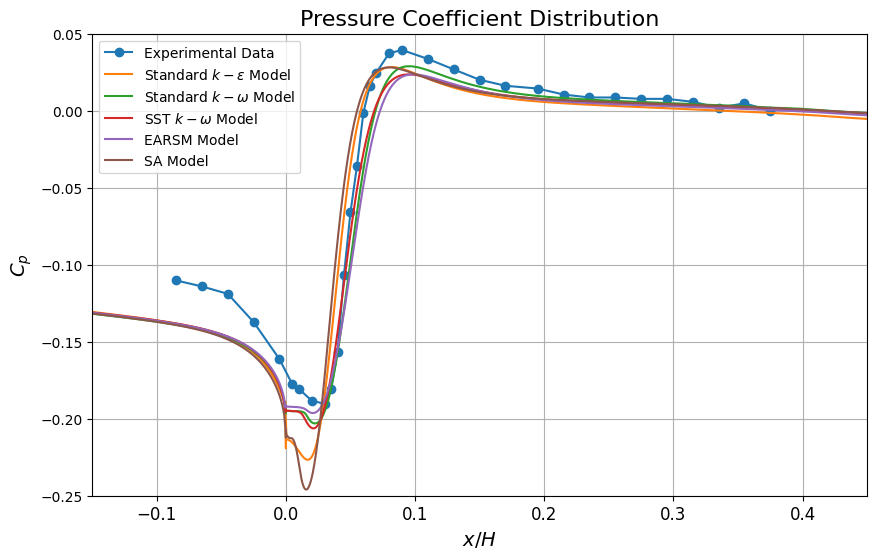

In [93]:
plt.figure(figsize=(10, 6))
plt.plot(df_theoretical['x_cp'].dropna()/100, df_theoretical['cp'].dropna(), label='Experimental Data', marker='o')
plt.plot(df_ke['x-cp-ke'], df_ke['cp-ke'], label=r'Standard $k-\varepsilon$ Model')
plt.plot(df_ko['x-cp-ko'], df_ko['cp-ko'], label=r'Standard $k-\omega$ Model')
plt.plot(df_ko_sst['x-cp-ko-sst'], df_ko_sst['cp-ko-sst'], label=r'SST $k-\omega$ Model')
plt.plot(df_earsm['x-cp-earsm'], df_earsm['cp-earsm'], label='EARSM Model')
plt.plot(df_sa['x-cp-sa'], df_sa['cp-sa'], label='SA Model')

plt.ylabel(r'$C_p$', fontsize=14)
plt.xlabel(r'$x/H$', fontsize=14)
plt.title(r'Pressure Coefficient Distribution', fontsize=16)
plt.xlim(-0.15, 0.45)
plt.ylim(-.25, 0.05)
plt.xticks(fontsize=12) 
plt.grid()
plt.legend()
plt.show()

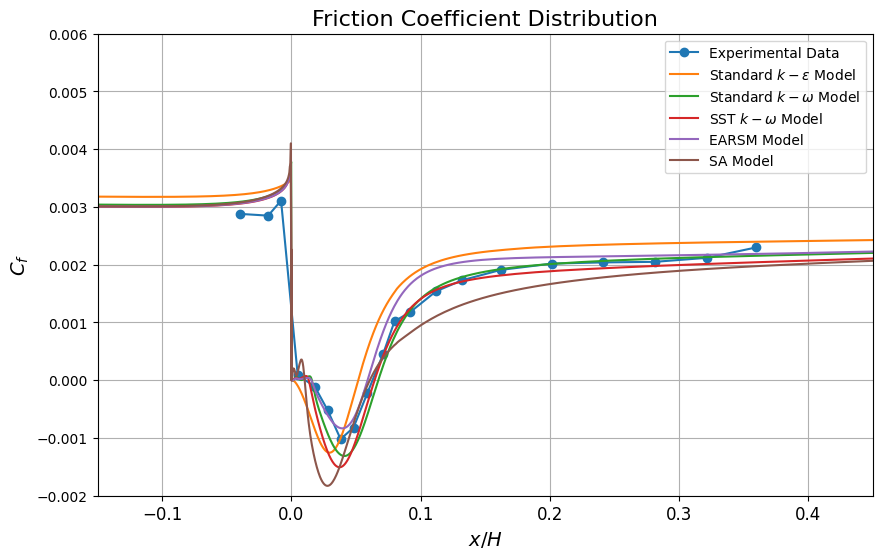

In [92]:
plt.figure(figsize=(10, 6))
plt.plot(df_theoretical['x_cf'].dropna()/100, df_theoretical['cf'].dropna(), label='Experimental Data', marker='o')
plt.plot(df_ke['x-cf-ke'], df_ke['cf-ke'], label=r'Standard $k-\varepsilon$ Model')
plt.plot(df_ko['x-cf-ko'], df_ko['cf-ko'], label=r'Standard $k-\omega$ Model')
plt.plot(df_ko_sst['x-cf-ko-sst'], df_ko_sst['cf-ko-sst'], label=r'SST $k-\omega$ Model')
plt.plot(df_earsm['x-cf-earsm'], df_earsm['cf-earsm'], label='EARSM Model')
plt.plot(df_sa['x-cf-sa'], df_sa['cf-sa'], label='SA Model')

plt.ylabel(r'$C_f$', fontsize=14)
plt.xlabel(r'$x/H$', fontsize=14)
plt.title(r'Friction Coefficient Distribution', fontsize=16)
plt.xlim(-0.15, 0.45)
plt.ylim(-0.002, 0.006)
plt.xticks(fontsize=12) 
plt.grid()
plt.legend()
plt.show()

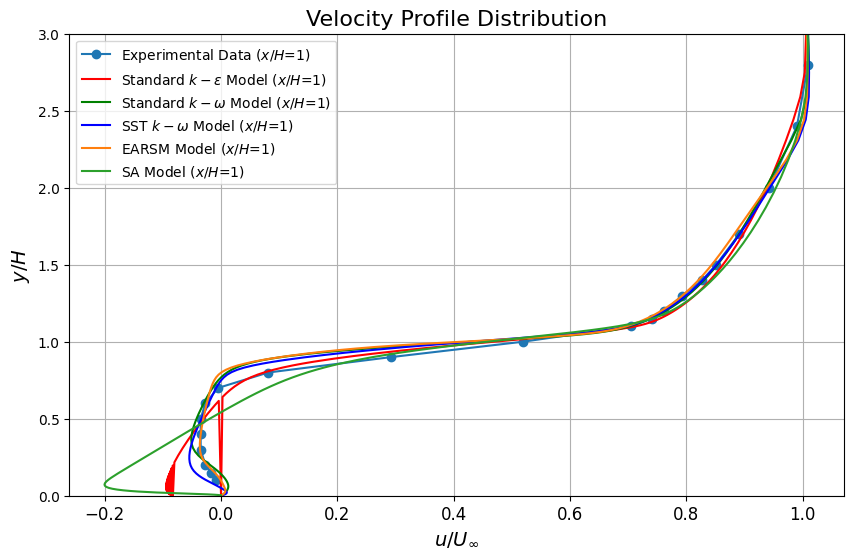

In [102]:
from turtle import color

from pyparsing import col


plt.figure(figsize=(10, 6))
plt.plot(df_theoretical['u1'].dropna(), df_theoretical['y1'].dropna(), label=r'Experimental Data ($x/H$=1)', marker='o')
plt.plot(df_ke['u1-ke'], df_ke['y1-ke'], label=r'Standard $k-\varepsilon$ Model ($x/H$=1)', color='red')
plt.plot(df_ko['u1-ko'], df_ko['y1-ko'], label=r'Standard $k-\omega$ Model ($x/H$=1)', color='green')
plt.plot(df_ko_sst['u1-ko-sst'], df_ko_sst['y1-ko-sst'], label=r'SST $k-\omega$ Model ($x/H$=1)', color='blue') 
plt.plot( df_earsm['u1-earsm'], df_earsm['y1-earsm'],label='EARSM Model ($x/H$=1)')
plt.plot(df_sa['u1-sa'], df_sa['y1-sa'], label='SA Model ($x/H$=1)')


plt.ylabel(r'$y/H$', fontsize=14)
plt.xlabel(r'$u/U_\infty$', fontsize=14)
plt.title(r'Velocity Profile Distribution', fontsize=16)
plt.ylim(0, 3)
plt.xticks(fontsize=12) 
plt.grid()
plt.legend()
plt.show()

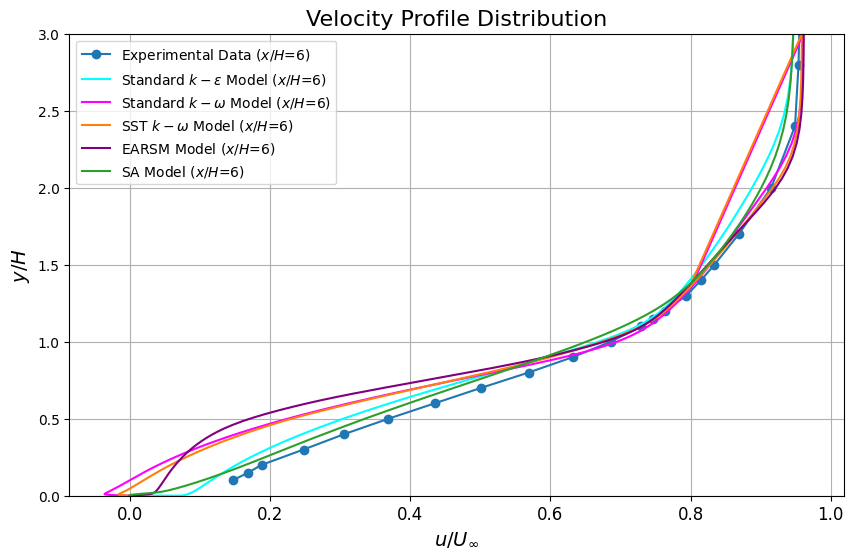

In [100]:
plt.figure(figsize=(10, 6))
plt.plot(df_theoretical['u6'].dropna(), df_theoretical['y6'].dropna(), label=r'Experimental Data ($x/H$=6)', marker='o')
plt.plot(df_ke['u6-ke'], df_ke['y6-ke'], label=r'Standard $k-\varepsilon$ Model ($x/H$=6)', color='cyan')
plt.plot(df_ko['u6-ko'], df_ko['y6-ko'], label=r'Standard $k-\omega$ Model ($x/H$=6)', color='magenta')
plt.plot(df_ko_sst['u6-ko-sst'], df_ko_sst['y6-ko-sst'], label=r'SST $k-\omega$ Model ($x/H$=6)')
plt.plot( df_earsm['u6-earsm'],df_earsm['y6-earsm'], label='EARSM Model ($x/H$=6)', color='purple') 
plt.plot(df_sa['u6-sa'], df_sa['y6-sa'], label='SA Model ($x/H$=6)')

plt.ylabel(r'$y/H$', fontsize=14)
plt.xlabel(r'$u/U_\infty$', fontsize=14)
plt.title(r'Velocity Profile Distribution', fontsize=16)
plt.ylim(0, 3)
plt.xticks(fontsize=12) 
plt.grid()
plt.legend()
plt.show()

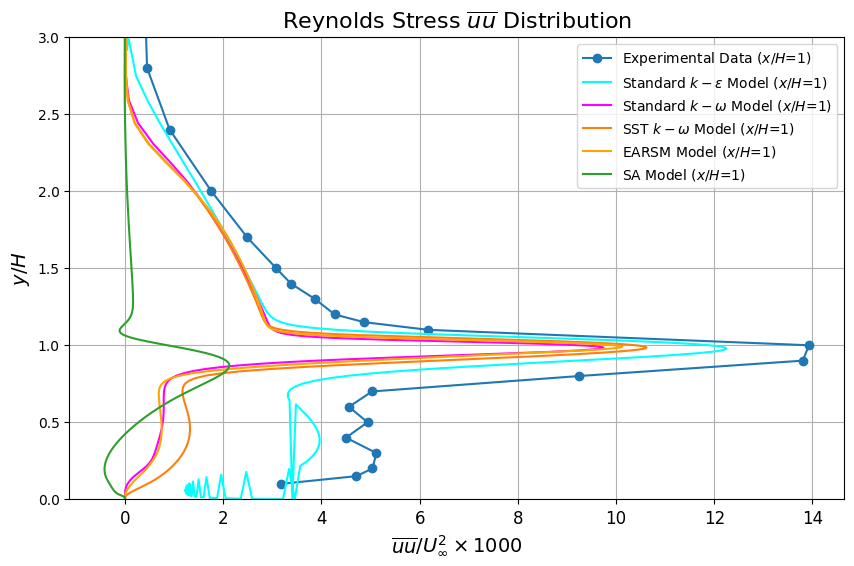

In [107]:
plt.figure(figsize=(10, 6))
plt.plot(df_theoretical['uu1'].dropna(), df_theoretical['y1'].dropna(), label=r'Experimental Data ($x/H$=1)', marker='o')
plt.plot(df_ke['uu1-ke'], df_ke['y1-ke'], label=r'Standard $k-\varepsilon$ Model ($x/H$=1)', color='cyan')
plt.plot(df_ko['uu1-ko'], df_ko['y1-ko'], label=r'Standard $k-\omega$ Model ($x/H$=1)', color='magenta')
plt.plot(df_ko_sst['uu1-ko-sst'], df_ko_sst['y1-ko-sst'], label=r'SST $k-\omega$ Model ($x/H$=1)')
plt.plot(df_earsm['uu1-earsm'], df_earsm['y1-earsm'], label='EARSM Model ($x/H$=1)', color='orange')
plt.plot(-df_sa['uu1-sa'], df_sa['y1-sa'], label='SA Model ($x/H$=1)')

plt.ylabel(r'$y/H$', fontsize=14)
plt.xlabel(r'$\overline{uu}/U_\infty^2 \times 1000$', fontsize=14)
plt.title(r'Reynolds Stress $\overline{uu}$ Distribution', fontsize=16)
plt.ylim(0, 3)
plt.xticks(fontsize=12) 
plt.grid()
plt.legend()
plt.show()


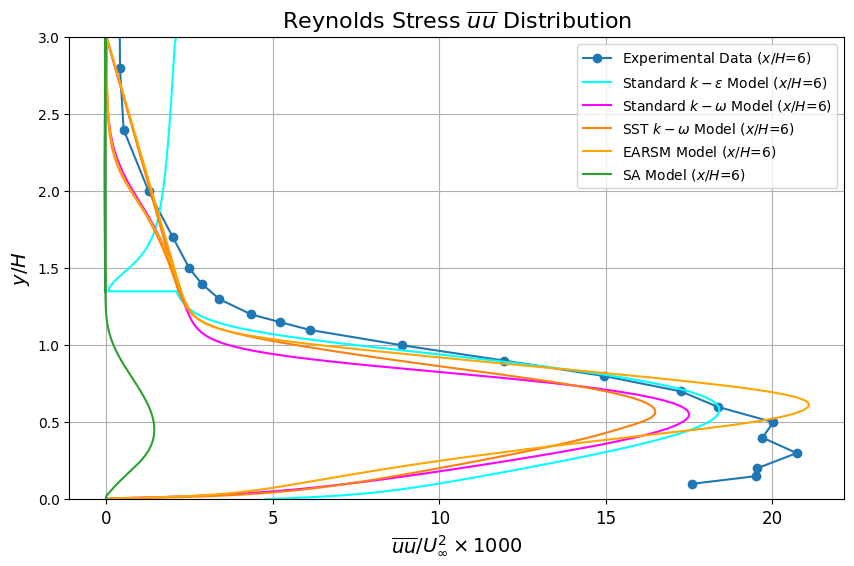

In [108]:
plt.figure(figsize=(10, 6))
plt.plot(df_theoretical['uu6'].dropna(), df_theoretical['y6'].dropna(), label=r'Experimental Data ($x/H$=6)', marker='o')
plt.plot(df_ke['uu6-ke'], df_ke['y6-ke'], label=r'Standard $k-\varepsilon$ Model ($x/H$=6)', color='cyan')
plt.plot(df_ko['uu6-ko'], df_ko['y6-ko'], label=r'Standard $k-\omega$ Model ($x/H$=6)', color='magenta')
plt.plot(df_ko_sst['uu6-ko-sst'], df_ko_sst['y6-ko-sst'], label=r'SST $k-\omega$ Model ($x/H$=6)')
plt.plot(df_earsm['uu6-earsm'], df_earsm['y6-uu6-earsm'], label='EARSM Model ($x/H$=6)', color='orange')
plt.plot(-df_sa['uu6-sa'], df_sa['y6-uu6-sa'], label='SA Model ($x/H$=6)')

plt.ylabel(r'$y/H$', fontsize=14)
plt.xlabel(r'$\overline{uu}/U_\infty^2 \times 1000$', fontsize=14)
plt.title(r'Reynolds Stress $\overline{uu}$ Distribution', fontsize=16)
plt.ylim(0, 3)
plt.xticks(fontsize=12) 
plt.grid()
plt.legend()
plt.show()


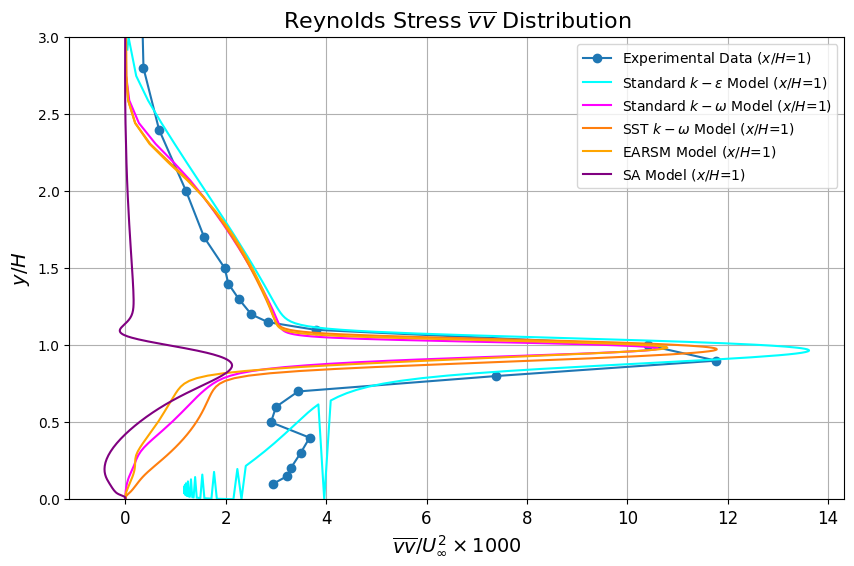

In [104]:
plt.figure(figsize=(10, 6))
plt.plot(df_theoretical['vv1'].dropna(), df_theoretical['y1'].dropna(), label=r'Experimental Data ($x/H$=1)', marker='o')
plt.plot(df_ke['vv1-ke'], df_ke['y1-ke'], label=r'Standard $k-\varepsilon$ Model ($x/H$=1)', color='cyan')
plt.plot(df_ko['vv1-ko'], df_ko['y1-ko'], label=r'Standard $k-\omega$ Model ($x/H$=1)', color='magenta')
plt.plot(df_ko_sst['vv1-ko-sst'], df_ko_sst['y1-ko-sst'], label=r'SST $k-\omega$ Model ($x/H$=1)')
plt.plot( df_earsm['vv1-earsm'], df_earsm['y1-vv1-earsm'],label='EARSM Model ($x/H$=1)', color='orange')
plt.plot(df_sa['vv1-sa'], df_sa['y1-vv1-sa'], label='SA Model ($x/H$=1)', color='purple')

plt.ylabel(r'$y/H$', fontsize=14)
plt.xlabel(r'$\overline{vv}/U_\infty^2 \times 1000$', fontsize=14)
plt.title(r'Reynolds Stress $\overline{vv}$ Distribution', fontsize=16)
plt.ylim(0, 3)
plt.xticks(fontsize=12) 
plt.grid()
plt.legend()
plt.show()

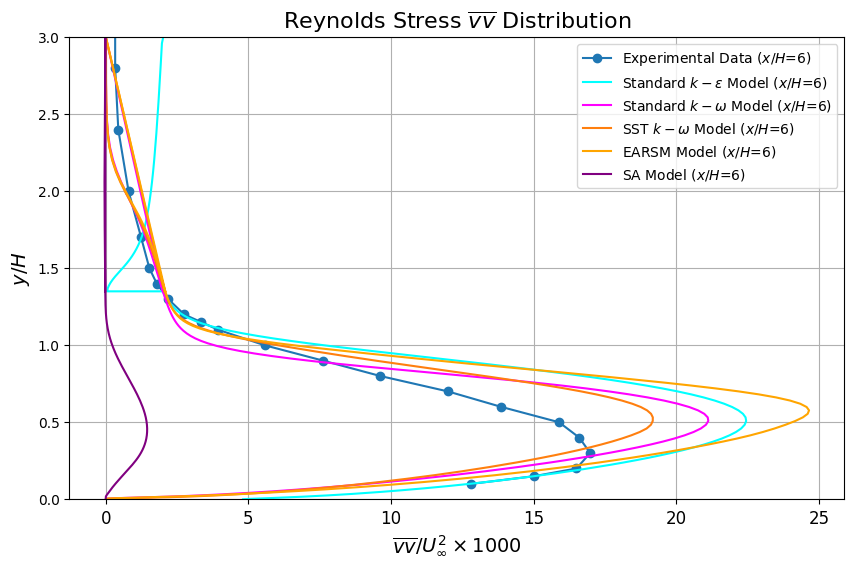

In [109]:
plt.figure(figsize=(10, 6))
plt.plot(df_theoretical['vv6'].dropna(), df_theoretical['y6'].dropna(), label=r'Experimental Data ($x/H$=6)', marker='o')
plt.plot(df_ke['vv6-ke'], df_ke['y6-ke'], label=r'Standard $k-\varepsilon$ Model ($x/H$=6)', color='cyan')
plt.plot(df_ko['vv6-ko'], df_ko['y6-ko'], label=r'Standard $k-\omega$ Model ($x/H$=6)', color='magenta')
plt.plot(df_ko_sst['vv6-ko-sst'], df_ko_sst['y6-ko-sst'], label=r'SST $k-\omega$ Model ($x/H$=6)')
plt.plot(df_earsm['vv6-earsm'], df_earsm['y6-vv6-earsm'], label='EARSM Model ($x/H$=6)', color='orange')
plt.plot(df_sa['vv6-sa'], df_sa['y6-vv6-sa'], label='SA Model ($x/H$=6)', color='purple')

plt.ylabel(r'$y/H$', fontsize=14)
plt.xlabel(r'$\overline{vv}/U_\infty^2 \times 1000$', fontsize=14)
plt.title(r'Reynolds Stress $\overline{vv}$ Distribution', fontsize=16)
plt.ylim(0, 3)
plt.xticks(fontsize=12) 
plt.grid()
plt.legend()
plt.show()

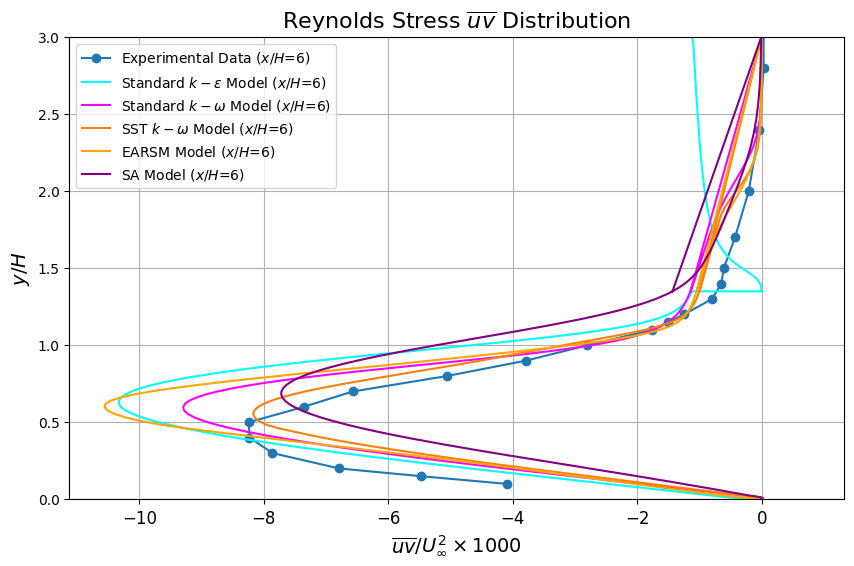

In [110]:
plt.figure(figsize=(10, 6))
plt.plot(df_theoretical['uv6'].dropna(), df_theoretical['y6'].dropna(), label=r'Experimental Data ($x/H$=6)', marker='o')
plt.plot(df_ke['uv6-ke'], df_ke['y6-ke'], label=r'Standard $k-\varepsilon$ Model ($x/H$=6)', color='cyan')
plt.plot(df_ko['uv6-ko'], df_ko['y6-ko'], label=r'Standard $k-\omega$ Model ($x/H$=6)', color='magenta')
plt.plot(df_ko_sst['uv6-ko-sst'], df_ko_sst['y6-ko-sst'], label=r'SST $k-\omega$ Model ($x/H$=6)')
plt.plot(df_earsm['uv6-earsm'], df_earsm['y6-uv6-earsm'], label='EARSM Model ($x/H$=6)', color='orange')
plt.plot(df_sa['uv6-sa'], df_sa['y6-uv6-sa'], label='SA Model ($x/H$=6)', color='purple')

plt.ylabel(r'$y/H$', fontsize=14)
plt.xlabel(r'$\overline{uv}/U_\infty^2 \times 1000$', fontsize=14)
plt.title(r'Reynolds Stress $\overline{uv}$ Distribution', fontsize=16)
plt.ylim(0, 3)
plt.xticks(fontsize=12) 
plt.grid()
plt.legend()
plt.show()

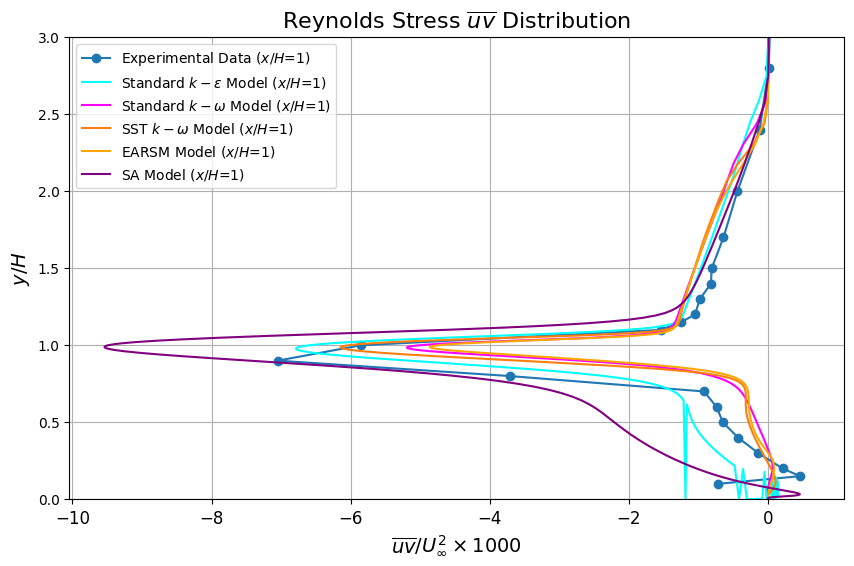

In [111]:
plt.figure(figsize=(10, 6))
plt.plot(df_theoretical['uv1'].dropna(), df_theoretical['y1'].dropna(), label=r'Experimental Data ($x/H$=1)', marker='o')
plt.plot(df_ke['uv1-ke'], df_ke['y1-ke'], label=r'Standard $k-\varepsilon$ Model ($x/H$=1)', color='cyan')
plt.plot(df_ko['uv1-ko'], df_ko['y1-ko'], label=r'Standard $k-\omega$ Model ($x/H$=1)', color='magenta')
plt.plot(df_ko_sst['uv1-ko-sst'], df_ko_sst['y1-ko-sst'], label=r'SST $k-\omega$ Model ($x/H$=1)')
plt.plot(df_earsm['uv1-earsm'], df_earsm['y1-uv1-earsm'], label='EARSM Model ($x/H$=1)', color='orange')
plt.plot(df_sa['uv1-sa'], df_sa['y1-uv1-sa'], label='SA Model ($x/H$=1)', color='purple')

plt.ylabel(r'$y/H$', fontsize=14)
plt.xlabel(r'$\overline{uv}/U_\infty^2 \times 1000$', fontsize=14)
plt.title(r'Reynolds Stress $\overline{uv}$ Distribution', fontsize=16)
plt.ylim(0, 3)
plt.xticks(fontsize=12) 
plt.grid()

plt.legend()
plt.show()